# Squeezing gastruloids

This program was developed for “article” (authors, year) using [CellBasedModels.jl](https://github.com/dsb-lab/CellBasedModels.jl).

The report and the rest of the code can be found on [GitHub](https://github.com/).

## Preamble

In [ ]:
using NBInclude
@nbinclude("preamble/packages.ipynb");
@nbinclude("preamble/functions-models.ipynb");
model = model_confined;

## Formation of the aggregate

### Initialization

In [3]:
parameters = define_par();                      # for default values. change: (...; fp=200) 

dt = 0.002;                                     # stable timestep. it may work for slightly higher values too.
save_each = round(Int64, 0.25 / dt);            # save community once every save_each instances
n_cells = 300;                                  # desired number of cells

Random.seed!(2345)                              # plant seed for reproducibility
com = initialize_growth(parameters; dt = dt);   # initialization. dt can also be set directy

com.L = 1 * (2*com.r)
com.rep_wall = com.rep

1-element Vector{Float64}:
 2.5

### Aggregation

In [4]:
grow_size!(com, save_each, n_cells)       # grow for a given n_cells
# grow_time!(com,save_each,30)            # grow for a given time, (...; n_cells=500)
# stabilize!(com, save_each)              # to let the cells accomodate when fp=0
m0 = length(com);

growncom = deepcopy(com);               # backup to go back

300
true


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/p9K7f/src/scenes.jl:264


Plot 1: timestamp 1
Plot 2: timestamp 50
Plot 3: timestamp 99
Plot 4: timestamp 149


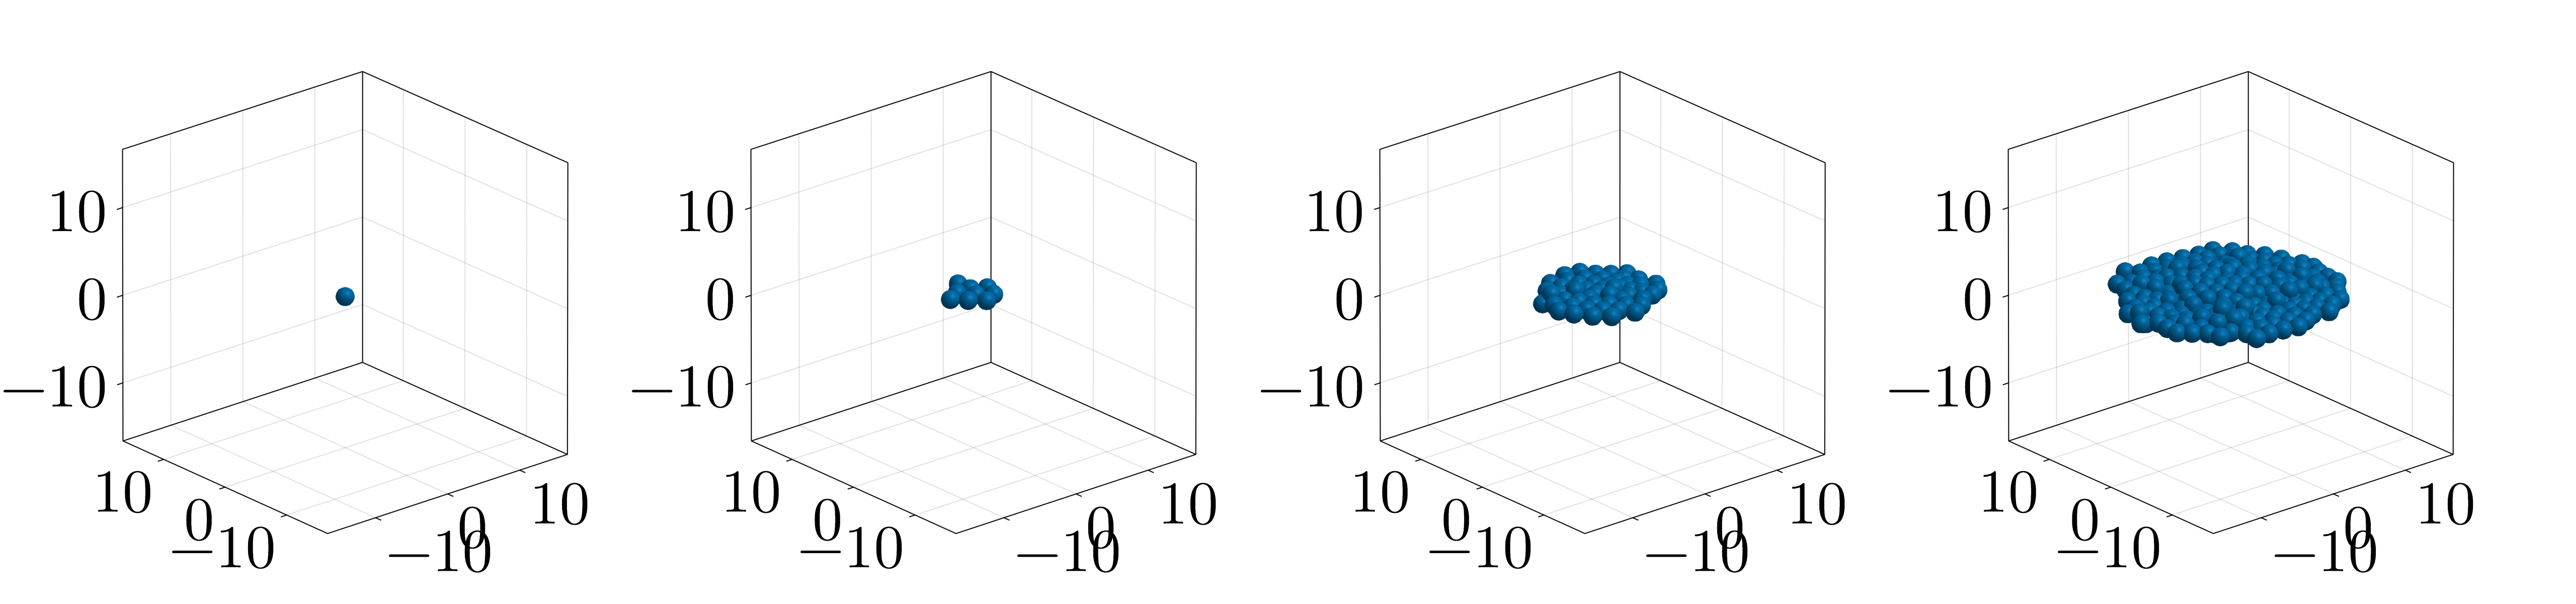

GLMakie.Screen(...)

In [5]:
println(com.N)
println(formed_correctly(com))          # no sparse cells caused by numerical errors
plot_aggregate(com, color_map, 1, m0)   # (...; size=float, showtime=false, shownumbers=true)

## Differentiation

In [6]:
com = deepcopy(growncom)
Random.seed!(2345);

In [7]:
initialize_diff!(com)                   # (...; g_on=false, treset=true)
m1 = length(com);

In [8]:
differentiate!(com, save_each, 30)      # (...; prot=true, fp=200, kp_on=0.7, kp_off=0.4)
# differentiate_all!(com,save_each)     # until all cells are in state C. same options as above.
m2 = length(com);

fp = 10
kp_on = 20
kp_off = 10


In [9]:
println(formed_correctly(com))

true


In [10]:
evolvedcom = deepcopy(com);

## Dimensionalization

In [11]:
com = deepcopy(evolvedcom);

In [12]:
dimensionalize_com!(com);       # (...; *=true, all=false) for *=t,r,xyz,f,v,lambda
# nondimensionalize_com!(com, all=true)     # reverts the changes

Plot 1: timestamp 150
Plot 2: timestamp 190
Plot 3: timestamp 230
Plot 4: timestamp 270


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/p9K7f/src/scenes.jl:264


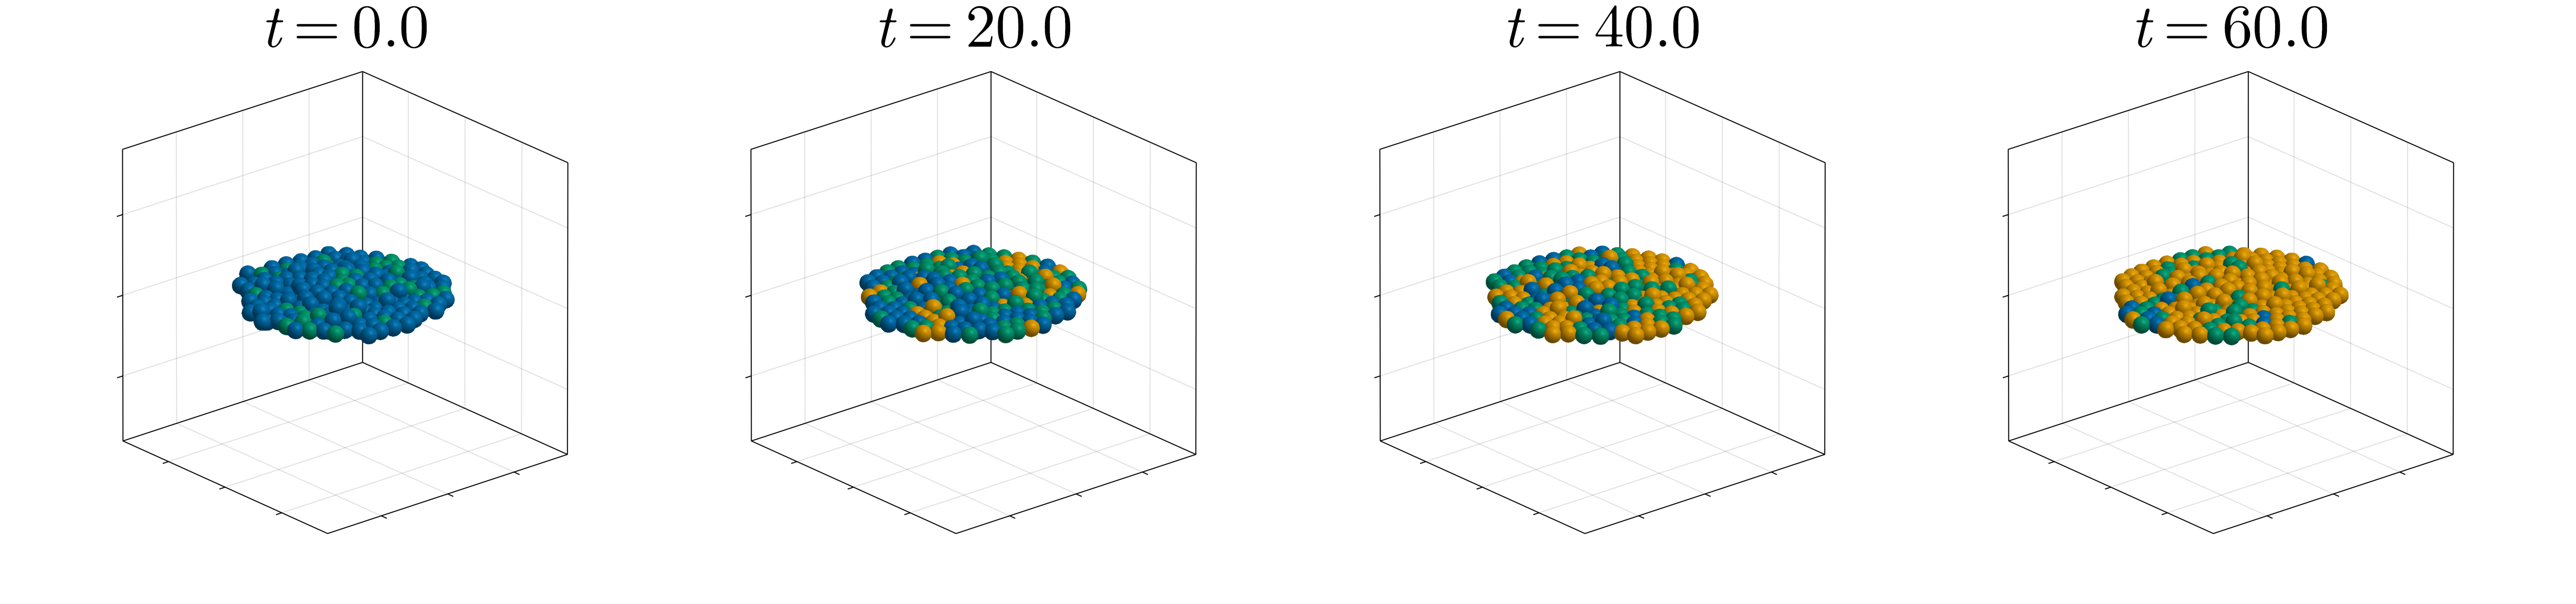

GLMakie.Screen(...)

In [13]:
plot_aggregate(com, color_map, m1, m2; showtime=true, shownumbers=false)

## Proportions

In [ ]:
props = get_props(com);      # compute proportion of each state for the saved timestamps

In [ ]:
plot_proportions(com, color_map, m1, m2, props)
# plot_proportions_analytical(com, color_map, m1, m2)
# plot_proportions_numerical_meanfield(com, color_map, m1, m2)
# plot_proportions_vs_analytical(com, color_map, m1, m2, props)
# plot_proportions_vs_meanfield(com, color_map, m1, m2, props)

## Movie

In [ ]:
prop = 1                                          # proportion of images used in the gif
n_images = round(Int, prop * (m2 - m1))
movie_frames(com, color_map, m1, m2, n_images)    # get plots
moment = Dates.format(now(), "mm-dd_HHMM");       # get date for the gif name

In [ ]:
run(`python3 images2gif.py $n_images $moment`)    # create gif from the plots

In [ ]:
delete_movieplots();                              # remove the plots

In [ ]:
variables = Dict()                     # store variabes defined in the code
for var in [:save_each, :m1, :m2]
	variables[var] = eval(var)
end

comvalues = [:N, :dt];                 # store community parameters

In [ ]:
file = "pymovie_$moment"
print_parameters(file, com, parameters, variables, comvalues);    # create file with values